# Task 8: fitting 50 MNIST images

We fit the first 50 training images of MNIST with only one hidden layer and quadratic loss.

We used a staged hyperparameter search to find a small network that reaches the target loss. The complete trial records are in `task8_results/`.

In [1]:
# Data loading
import gzip
import pickle
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

with gzip.open("mnist.pkl.gz", "rb") as file:
    (train_images, train_labels), _, _ = pickle.load(file, encoding="latin1")
X = train_images[:50].astype(float)
labels = train_labels[:50].astype(int)
Y = np.eye(10)[labels]
A = np.c_[X, np.ones(50)]  # bias input
print(X.shape, Y.shape)

(50, 784) (50, 10)


In [2]:
# ANN structure and backpropagation

def sigmoid(z):
    return 0.5 * (1 + np.tanh(z / 2))


def activation(z, kind):
    if kind == "sigmoid":
        a = sigmoid(z)
        return a, a * (1 - a)
    if kind == "softplus":
        return np.logaddexp(0, z), sigmoid(z)
    if kind == "leaky_relu":
        return np.maximum(z, 0.1 * z), np.where(z > 0, 1.0, 0.1)
    if kind == "relu":
        return np.maximum(z, 0), (z > 0).astype(float)
    raise ValueError(kind)


def initial_weights(width, seed, hidden, output):
    rng = np.random.default_rng(seed)
    scale = np.sqrt(2) if hidden == "leaky_relu" else 1
    W1 = rng.normal(0, scale / np.sqrt(785), (width, 785))
    W2 = rng.normal(0, 1 / np.sqrt(width + 1), (10, width + 1))
    if output == "relu":
        W2[:, -1] = 0.1  # keep more ReLU outputs active at initialization
    return np.r_[W1.ravel(), W2.ravel()]


def unpack(weights, width):
    # unpack the weights vector into two matrices.
    cut = 785 * width
    return weights[:cut].reshape(width, 785), weights[cut:].reshape(10, width + 1)


def loss_and_gradient(weights, width, hidden, output, order=None):
    W1, W2 = unpack(weights, width)

    # Input -> Hidden
    inputs = A if order is None else A[order] # already biased
    targets = Y if order is None else Y[order]
    H, dH = activation(inputs @ W1.T, hidden)

    # Hidden -> Output
    H_bias = np.c_[H, np.ones(len(inputs))]
    prediction, d_output = activation(H_bias @ W2.T, output)

    # Quadratic loss
    error = prediction - targets
    n = len(inputs)
    loss = np.sum(error**2) / (2 * n)

    # Compute gradients
    d2 = error * d_output / n
    d1 = (d2 @ W2[:, :-1]) * dH
    g1 = d1.T @ inputs
    g2 = d2.T @ H_bias
    return loss, np.r_[g1.ravel(), g2.ravel()]

### Training

Backpropagation gives the gradient of the same quadratic loss used for evaluation. We compare Adam with the code's SGD branch using a batch size of 50 (equivalent to full-batch gradient descent). Each update uses all 50 images, so one update is one epoch. We record the first epoch below $10^{-8}$ and save the weights with the smallest loss.

In [3]:
def train(width, hidden, output, seed, lr, max_epochs, method="Adam",
          stop_at_target=False):
    weights = initial_weights(width, seed, hidden, output)
    rng = np.random.default_rng(seed + 1000)
    momentum = np.zeros_like(weights)
    scale = np.zeros_like(weights)
    best_loss = np.inf
    best_weights = weights.copy()
    first_below = None
    curve = []

    for epoch in range(1, max_epochs + 1):
        _, gradient = loss_and_gradient(
            weights, width, hidden, output, rng.permutation(50))
        if method == "Adam":
            momentum = 0.9 * momentum + 0.1 * gradient
            scale = 0.999 * scale + 0.001 * gradient**2
            weights -= lr * (momentum / (1 - 0.9**epoch)) / (
                np.sqrt(scale / (1 - 0.999**epoch)) + 1e-8)
        else:
            weights -= lr * gradient

        loss, _ = loss_and_gradient(weights, width, hidden, output)
        if loss < best_loss:
            best_loss, best_weights = loss, weights.copy()
        if first_below is None and loss < 1e-8:  # threshold
            first_below = epoch
        if epoch == 1 or epoch % 100 == 0 or first_below == epoch:
            curve.append((epoch, loss))
        if stop_at_target and first_below is not None:
            break

    return best_weights, first_below, best_loss, np.array(curve)

### Search and selected runs

We searched hyperparameters in three stages, with the following settings and number of runs:

| Stage | Settings explored | Runs |
| --- | --- | ---: |
| Sigmoid baseline | Hidden widths 2, 3, 4, 8; Adam, full batch, learning rate 0.01, up to 20 seeds and 50,000 epochs | 71 |
| Activation search | Width 2; first 5 hidden × 3 output activations with seeds 0–4 at learning rate 0.01. We then focused on softplus/ReLU and leaky ReLU/ReLU, trying seeds up to 99, learning rates 0.001–0.1, batches of 10 or 50, plus a few SGD runs for comparison | 578 |
| Bias check | Width 2, leaky ReLU/ReLU; output bias 0.5, 30 seeds and four learning rates | 120 |

To keep the notebook readable, we kept the additional activation search in `task8_results/search_common.py`.
The complete records are located in `task8_results/`. Some settings were repeated with different epoch limits. 

The four runs shown below are a sigmoid reference, two successful width-2 choices, and an SGD comparison. This cell retrains them with fixed seeds.

In [4]:
results_dir = Path("task8_results")
results_dir.mkdir(exist_ok=True)
experiments = [
    (3, "sigmoid", "sigmoid", 18, 0.01, 50000, "Adam"),
    (2, "softplus", "relu", 38, 0.01, 3000, "Adam"),
    (2, "leaky_relu", "relu", 14, 0.012, 3000, "Adam"),
    (2, "leaky_relu", "relu", 14, 0.1, 5000, "SGD"),
]
runs = []
print("h  hidden       output   method  first epoch   minimum loss")
for width, hidden, output, seed, lr, epochs, method in experiments:
    weights, first, loss, curve = train(
        width, hidden, output, seed, lr, epochs, method,
        stop_at_target=(width == 3))
    runs.append((width, hidden, output, method, seed, first, loss, curve))
    np.savez(results_dir / f"task8_{hidden}_{output}_{method}_s{seed}.npz",
             weights=weights, first_below=first if first is not None else -1,
             loss=loss, curve=curve)
    print(f"{width:<2} {hidden:<12} {output:<8} {method:<7} "
          f"{str(first):<13} {loss:.3e}")

h  hidden       output   method  first epoch   minimum loss
3  sigmoid      sigmoid  Adam    39506         9.999e-09
2  softplus     relu     Adam    1179          1.313e-31
2  leaky_relu   relu     Adam    998           1.213e-31
2  leaky_relu   relu     SGD     None          6.107e-02


### Convergence

The plot shows the raw loss for successful runs on log scales. Adam can overshoot after crossing the target, so the saved checkpoint uses the smallest loss observed during training.

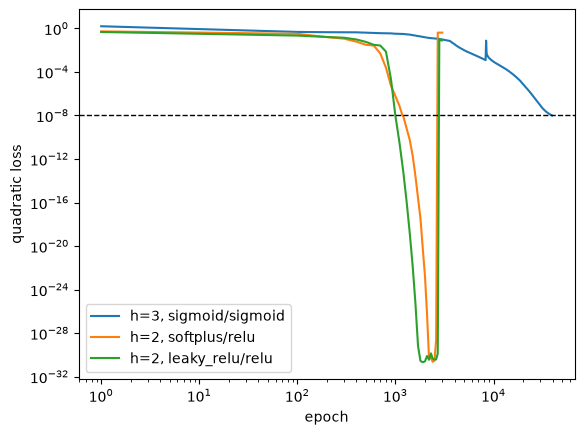

In [5]:
for width, hidden, output, method, seed, first, loss, curve in runs:
    if first is not None:
        plt.plot(curve[:, 0], curve[:, 1],
                 label=f"h={width}, {hidden}/{output}")
plt.axhline(1e-8, color="black", linestyle="--", linewidth=1)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("epoch")
plt.ylabel("quadratic loss")
plt.legend()
plt.show()

### Findings

In the notebook rerun, the 3-neuron sigmoid baseline first crossed $10^{-8}$ at epoch 39,506. However, none of the 20 two-neuron runs reached the target within 50,000 epochs in the earlier sigmoid search. With 2 neurons, softplus/ReLU crossed at epoch 1,179 and leaky ReLU/ReLU with full-batch Adam (learning rate 0.012, seed 14) at epoch 998; the latter reached a smallest saved loss of 

$$
1.21\times10^{-31}.
$$ 




In these runs, two-neuron networks with a ReLU output and either softplus or leaky ReLU hidden activation reached the target faster than the sigmoid/sigmoid reference. Other activation pairs and seeds did not always succeed.

## Another possibility: One hidden neuron with a sophisticated activation function

However, there is still another trivial solution to the 50-sample problem. As the project2 handout notes, we may choose arbitrary activation functions for this task. Since we only want to fit the specific 50 samples, we can construct a single hidden neuron with a custom activation function that maps each input to its corresponding label, which will result in **ZERO** loss on the given data.

This method is not practical for generalization and feels like playing with words, but we still mention it here since it is a valid solution to the problem. One can judge by themselves whether this is a "cheat" or a clever solution :)

### Constructing the output activation
Trivially, one can build the output activation from the 50 training samples and their labels. 

The hidden neuron outputs $t(x)=\operatorname{sigmoid}(w^\top x)$. There are still ten output neurons. For output neuron $k$, set its weight from the hidden neuron to $1$ and its bias to $2k$. Its input before activation is

$$
z_k(x)=t(x)+2k,
$$

and its final output is $h_k(x)=g(z_k(x))$. All ten output neurons use the same activation function $g$, in which we want to store the labeling information.

For the 50 training samples, write $t_i=t(x_i)$ and choose $w$ so that these values are distinct. Set $r=\frac13\min_{i\ne j}|t_i-t_j|$. Using their labels $\ell_i$, define

$$
g(z)=\sum_{i=1}^{50}
\left[\max\left(1-\left(\frac{z-(t_i+2\ell_i)}{r}\right)^2,\,0\right)\right]^2.
$$

This places a narrow peak at $t_i+2\ell_i$. On sample $x_i$, the correct output neuron has $z_{\ell_i}(x_i)=t_i+2\ell_i$, exactly at that peak, so it outputs $1$. Every other output neuron is outside all peaks and outputs $0$.

In [10]:
# Construct the shared activation and check its raw training loss.
custom_rng = np.random.default_rng(0) # set random seed

# t_i: Input -> Hidden
custom_W1 = np.r_[custom_rng.normal(0, 1 / np.sqrt(784), 784), 0].reshape(1, 785)
custom_t = sigmoid(A @ custom_W1.T).ravel()

custom_gap = np.diff(np.sort(custom_t)).min()
assert custom_gap > 0
custom_radius = custom_gap / 3
custom_centers = custom_t + 2 * labels


def custom_activation(z):
    u = (np.asarray(z)[..., None] - custom_centers) / custom_radius
    return (np.maximum(1 - u**2, 0)**2).sum(axis=-1)

custom_hidden = sigmoid(A @ custom_W1.T)
custom_hidden_bias = np.c_[custom_hidden, np.ones(len(X))]
custom_W2 = np.c_[np.ones(10), 2 * np.arange(10)]

# Hidden -> Output
custom_output = custom_activation(custom_hidden_bias @ custom_W2.T)

custom_loss = np.sum((custom_output - Y)**2) / (2 * len(X))
custom_error = np.max(np.abs(custom_output - Y))

assert custom_output.shape == (50, 10)
print(f"Hidden neurons: 1")
print(f"Raw quadratic training loss: {custom_loss:.3e}")
print(f"Maximum output error: {custom_error:.3e}")
# We can "train" this network, but it won't have any weight updates
if custom_loss < 1e-8:
    print("Target met before training; 0 gradient updates.")

Hidden neurons: 1
Raw quadratic training loss: 0.000e+00
Maximum output error: 0.000e+00
Target met before training; 0 gradient updates.


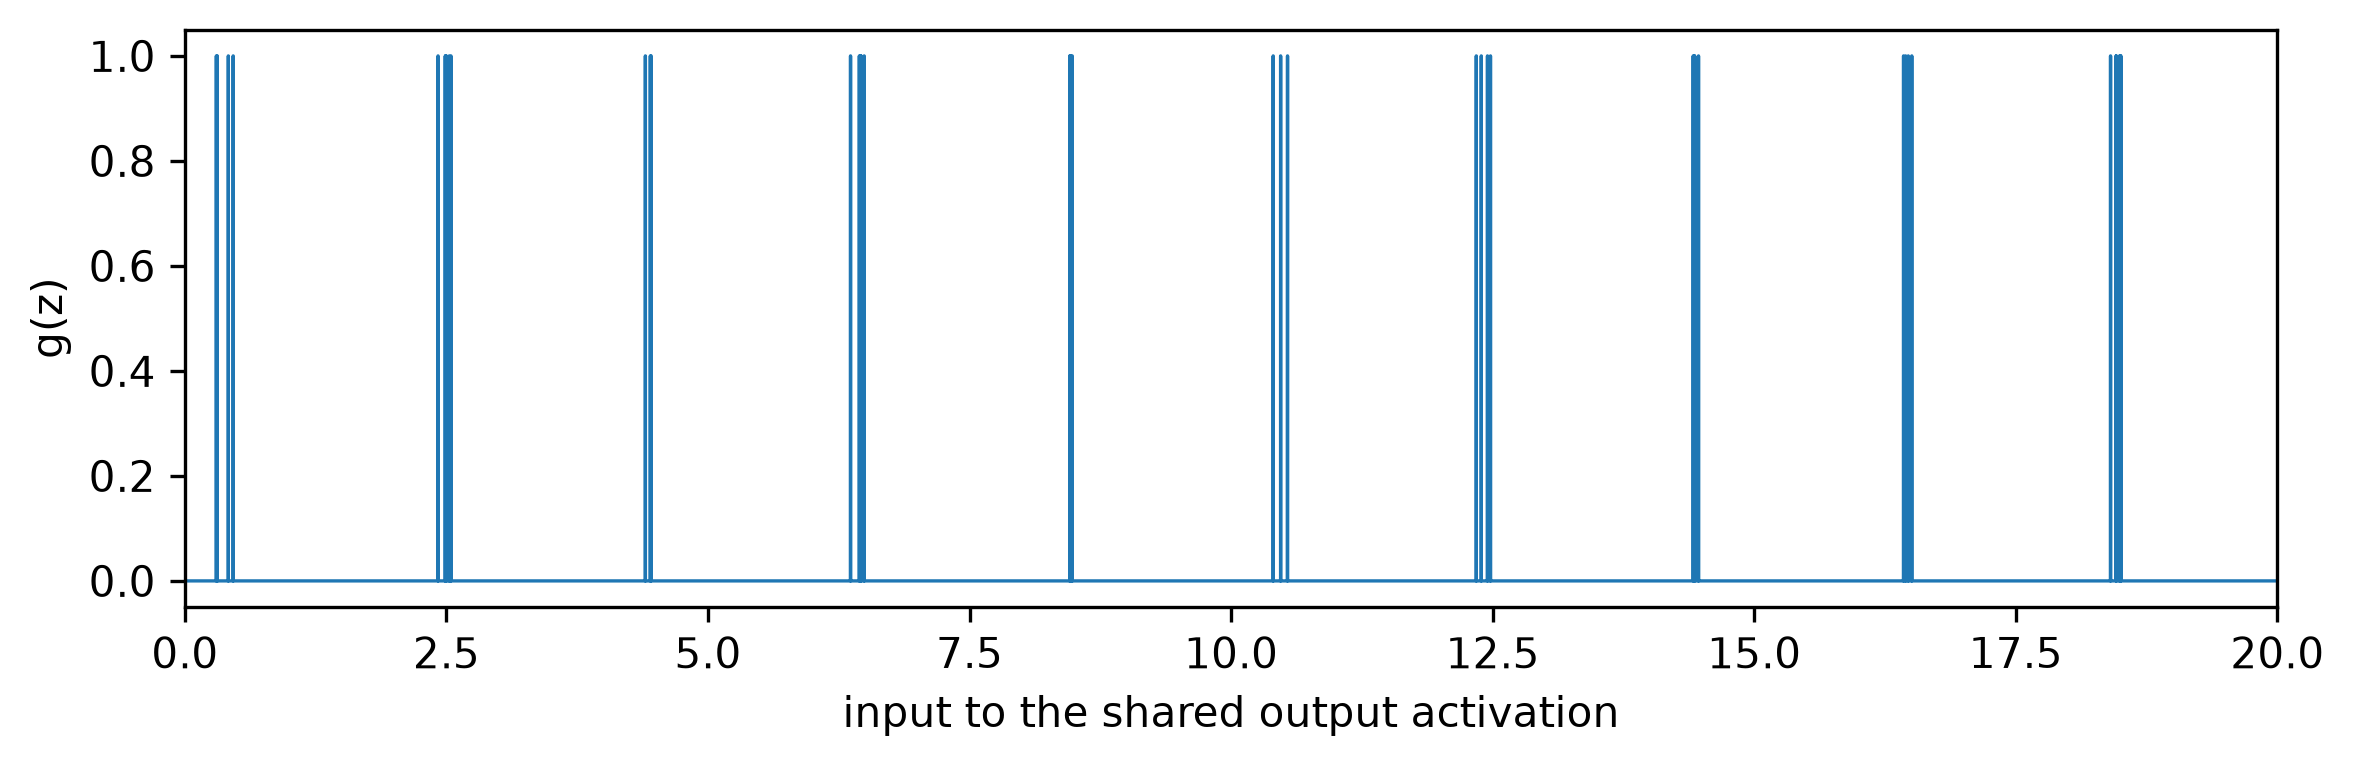

In [13]:
# Sample around each narrow peak so the plot does not miss them.
custom_offsets = np.linspace(-1.2, 1.2, 25)
custom_grid = np.sort(np.r_[
    0, 20,
    (custom_centers[:, None] + custom_radius * custom_offsets).ravel()
])
plt.figure(figsize=(9, 2.5), dpi=300)
plt.plot(custom_grid, custom_activation(custom_grid), linewidth=0.8)
plt.xlim(0, 20)
plt.ylim(-0.05, 1.05)
plt.xlabel("input to the shared output activation")
plt.ylabel("g(z)")
plt.show()

The network has one hidden neuron, but its activation contains 50 label-dependent peaks. It reaches the target on the training samples without a gradient update, which means the network fits the data perfectly from the start.